# **DA2101 ASSIGNMENT-5**

**AUTHOR : VISHWANATH VINOD**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import nbformat, base64, re
from pathlib import Path
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
import math

nb_file = "ee22b002_5.ipynb"

# Load notebook
nb = nbformat.read(nb_file, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "markdown":
        matches = re.findall(r'!\[\]\((.*?)\)', cell.source)
        for img_path in matches:
            path = Path(img_path)
            if path.exists():
                ext = path.suffix[1:]  # e.g., 'jpg' or 'png'
                data = base64.b64encode(path.read_bytes()).decode()
                img_tag = f'<img src="data:image/{ext};base64,{data}">'
                cell.source = cell.source.replace(f"![]({img_path})", img_tag)

# Save notebook with embedded images
nbformat.write(nb, "ee22b002_5.ipynb")


### **PROBLEM-1**

Consider the simple pendulum **without damping** and **without assuming small oscillations**.  The governing equation is given by:

$l \frac{d^2\theta}{dt^2} + c \frac{d\theta}{dt} + g \sin(\theta) = 0$

Take the following parameters:

$l = 1, \quad c = 10^{-4}, \quad g = 9.81$


1. Write a Python code to determine the trajectory of the pendulum till $T = 10$ seconds using the following numerical integration methods:

    1. Euler Explicit
    2. Euler Implicit
    3. Trapezoidal
    4. Runge–Kutta 2 (RK2)
    5. Runge–Kutta 4 (RK4)

Vary the time step $\Delta t$ as $\Delta t \in \{1, \, 10^{-1}, \, 10^{-2}, \, 10^{-3}, \, 10^{-4}, \, 10^{-5}\}$

b) Comment on the stability, accuracy and phase shifts of these integration methods.


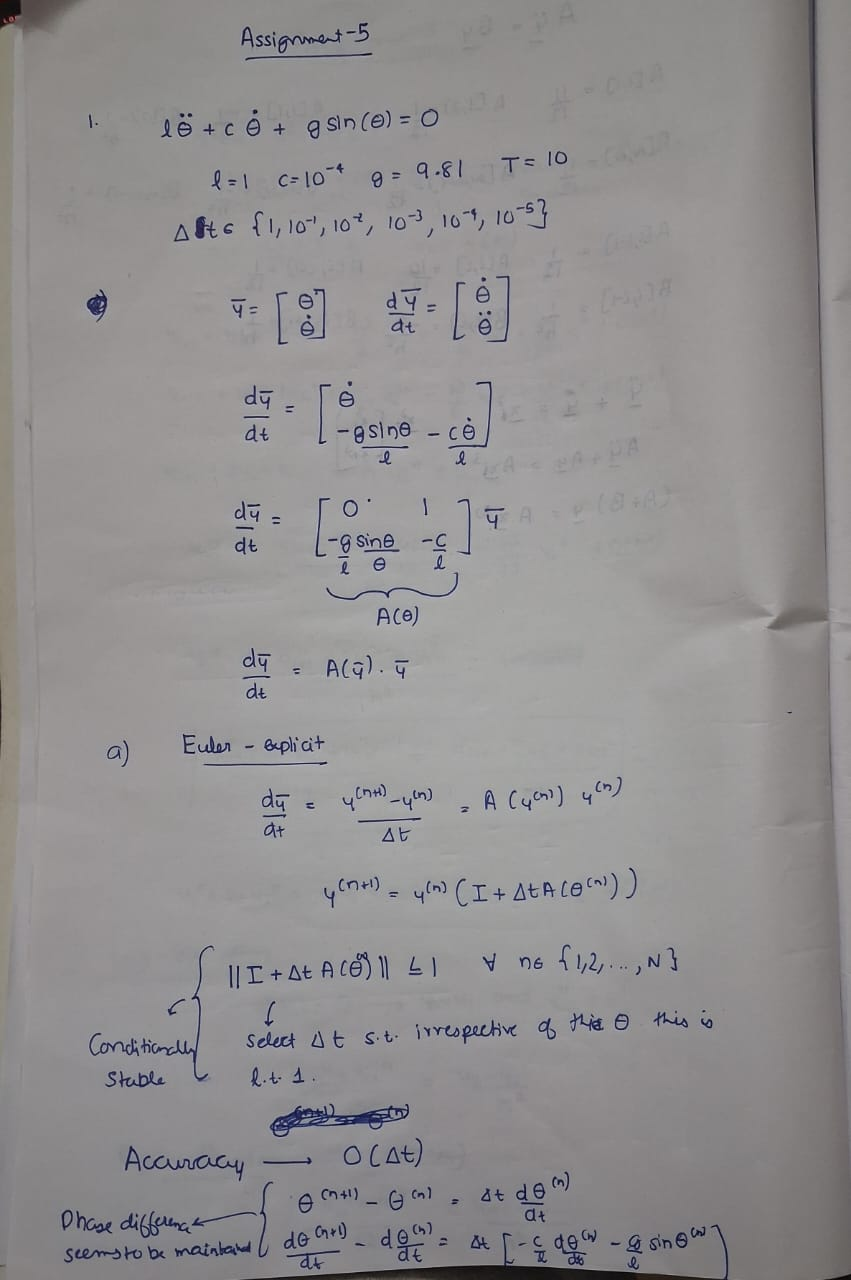

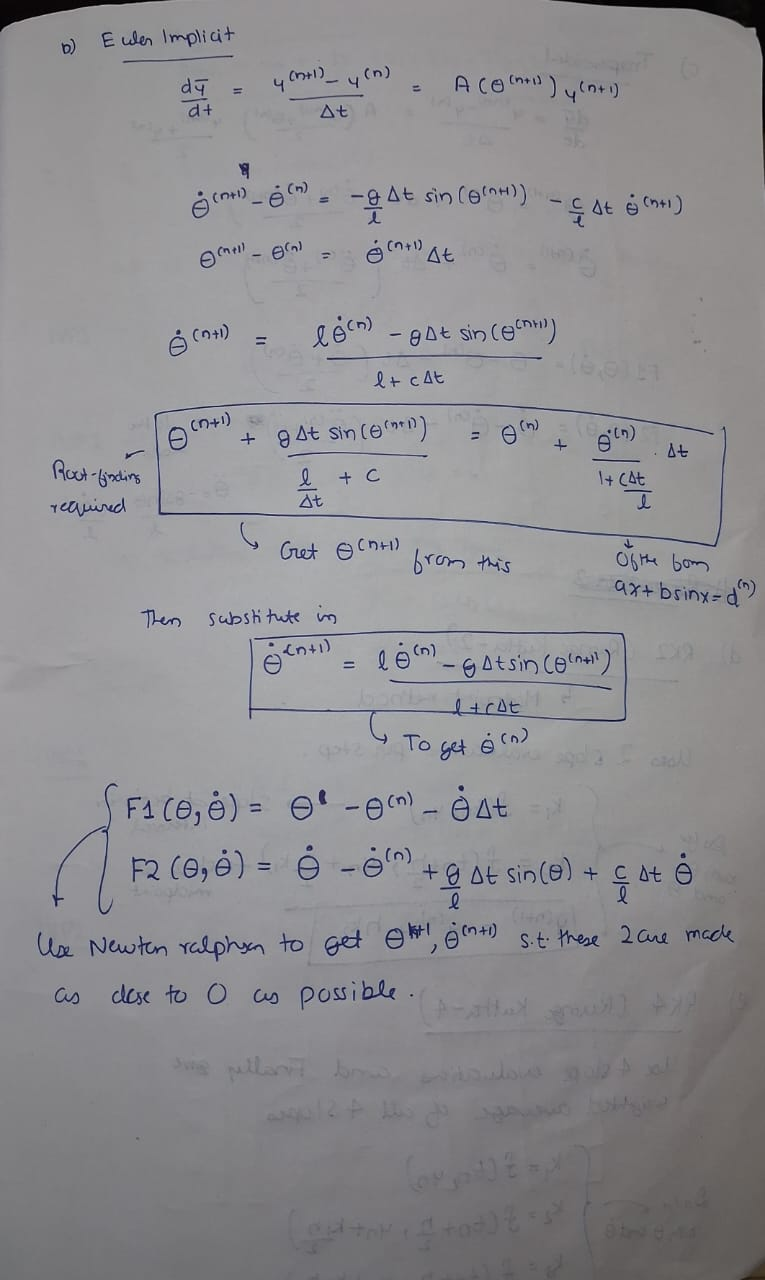

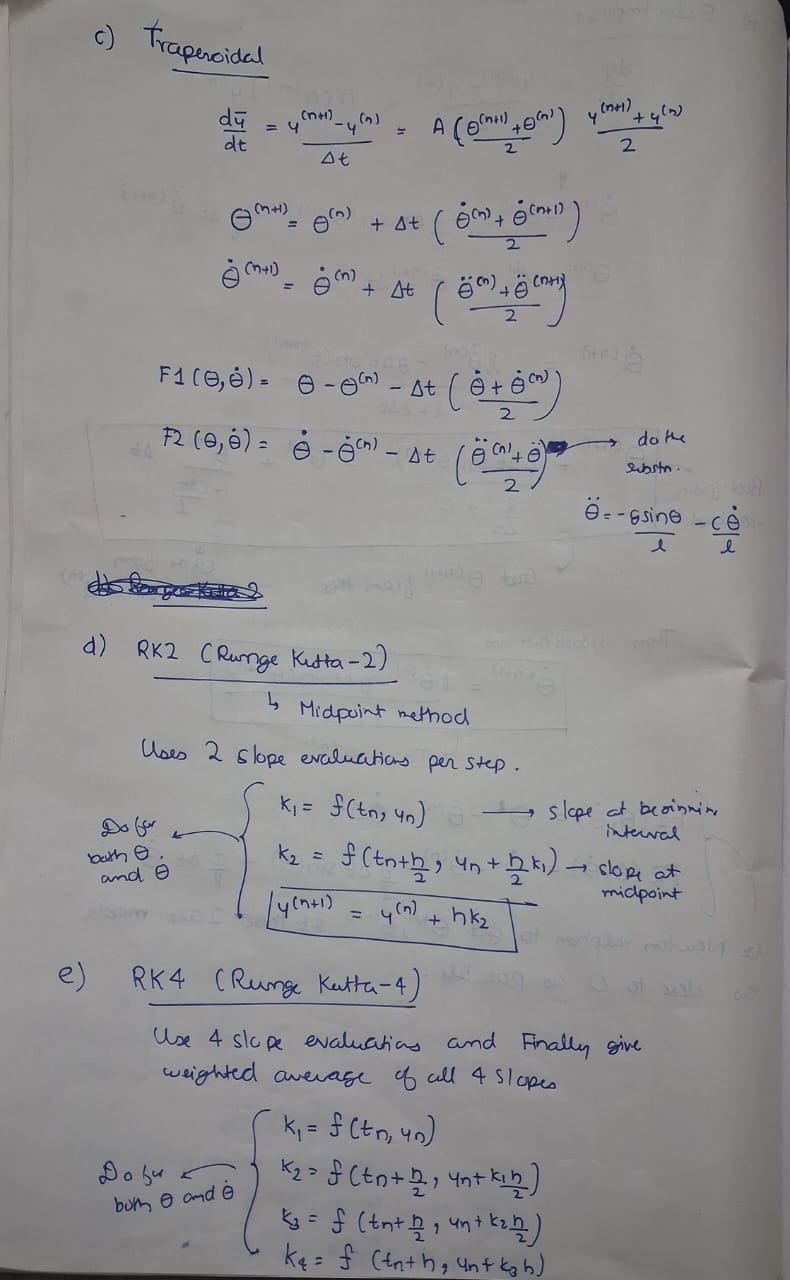

In [58]:
class Pendulum():
    def __init__(self,theta0,omega0,dt=1):
        self.l = 1
        self.c = 1e-4
        self.g = 9.81
        self.T = 10
        self.dt = dt
        self.theta0 = theta0
        self.omega0 = omega0 #theta_prime
        self.n_steps = int(np.ceil(self.T /self.dt))

    def double_drvtv(self,theta,omega):
        return (-self.c * omega - self.g * np.sin(theta)) / self.l

    def euler_explicit(self):
        t = np.linspace(0, self.n_steps*self.dt, self.n_steps+1)
        theta = np.zeros(self.n_steps+1)
        omega = np.zeros(self.n_steps+1)
        theta[0] = self.theta0
        omega[0] = self.omega0
        for n in range(self.n_steps):
            theta[n+1] = theta[n] + self.dt * omega[n]
            omega[n+1] = omega[n] + self.dt * self.double_drvtv(theta[n], omega[n])
        return t, theta, omega
    
    def euler_implicit_newton(self,newton_tol=1e-10, newton_maxiter=40):
        t = np.linspace(0, self.n_steps*self.dt, self.n_steps+1)
        theta = np.zeros(self.n_steps+1)
        omega = np.zeros(self.n_steps+1)
        theta[0] = self.theta0
        omega[0] = self.omega0

        for n in range(self.n_steps):
            theta_n, omega_n = theta[n], omega[n]

            # Predictor (explicit Euler)
            theta_guess = theta_n + self.dt * omega[n]
            omega_guess = omega_n + self.dt * self.double_drvtv(theta[n], omega[n])
            x = np.array([theta_guess, omega_guess], dtype=float)

            for k in range(newton_maxiter):
                thetak, omegak = x[0], x[1]

                #Residual (F1,F2) substitutes the predicted value in eqn and aims to make the residuals 0 which will give the actual value of theta and omega at n+1
                F1 = thetak - theta_n - self.dt * omegak
                F2 = omegak - omega_n + self.dt * (self.c * omegak + self.g * np.sin(thetak)) / self.l
                F = np.array([F1, F2], dtype=float)

                # Jacobian matrix J = ∂F/∂(theta, omega)
                dF1_dtheta = 1.0
                dF1_domega = -self.dt
                dF2_dtheta = self.dt * (self.g * np.cos(thetak)) / self.l
                dF2_domega = 1.0 + self.dt * (self.c / self.l)

                J = np.array([[dF1_dtheta, dF1_domega],[dF2_dtheta, dF2_domega]], dtype=float)

                try:
                    dx = np.linalg.solve(J, -F)
                except np.linalg.LinAlgError:
                    raise RuntimeError(f"Singular Jacobian during Newton at step {n}, iter {k}")

                x = x + dx
                if np.linalg.norm(dx) < newton_tol:
                    break
            else:
                print(f"Newton failed to converge at step {n+1} (implicit Euler).")
                theta[n+1] = theta[n] + self.dt * omega[n]
                omega[n+1] = omega[n] + self.dt * self.double_drvtv(theta[n], omega[n])

            theta[n+1], omega[n+1] = x[0], x[1]

        return t, theta, omega
    
    def trapezoidal_newton(self, newton_tol=1e-10, newton_maxiter=40):
        t = np.linspace(0, self.n_steps * self.dt, self.n_steps + 1)
        theta = np.zeros(self.n_steps + 1)
        omega = np.zeros(self.n_steps + 1)
        theta[0] = self.theta0
        omega[0] = self.omega0

        for n in range(self.n_steps):
            theta_n, omega_n = theta[n], omega[n]
            a_n = self.double_drvtv(theta_n, omega_n)

            # Predictor (explicit Euler)
            theta_guess = theta_n + self.dt * omega_n
            omega_guess = omega_n + self.dt * a_n
            x = np.array([theta_guess, omega_guess], dtype=float)

            for k in range(newton_maxiter):
                thetak, omegak = x[0], x[1]
                a_k = self.double_drvtv(thetak, omegak)

                # Residuals
                F1 = thetak - theta_n - (self.dt / 2.0) * (omega_n + omegak)
                F2 = omegak - omega_n - (self.dt / 2.0) * (a_n + a_k)
                F = np.array([F1, F2], dtype=float)

                # Jacobian matrix J = ∂F/∂(theta, omega)
                dF1_dtheta = 1.0
                dF1_domega = -self.dt / 2.0
                dF2_dtheta = (self.dt / 2.0) * (self.g * np.cos(thetak)) / self.l
                dF2_domega = 1.0 + (self.dt / 2.0) * (self.c / self.l)

                J = np.array([[dF1_dtheta, dF1_domega],[dF2_dtheta, dF2_domega]], dtype=float)

                try:
                    dx = np.linalg.solve(J, -F)
                except np.linalg.LinAlgError:
                    raise RuntimeError(f"Singular Jacobian at step {n}, iteration {k} (trapezoidal).")

                x += dx
                if np.linalg.norm(dx) < newton_tol:
                    break
            else:
                raise RuntimeError(f"Newton did not converge at step {n+1} (trapezoidal).")

            theta[n + 1], omega[n + 1] = x[0], x[1]

        return t, theta, omega
    
    def rk2(self):
        t = np.linspace(0, self.n_steps * self.dt, self.n_steps + 1)
        theta = np.zeros(self.n_steps + 1)
        omega = np.zeros(self.n_steps + 1)
        theta[0] = self.theta0
        omega[0] = self.omega0

        for n in range(self.n_steps):
            theta_n, omega_n = theta[n], omega[n]

            #First slope evaluation at tn
            k1_theta = omega_n
            k1_omega = self.double_drvtv(theta_n, omega_n)
            theta_mid = theta_n + 0.5 * self.dt * k1_theta
            omega_mid = omega_n + 0.5 * self.dt * k1_omega

            #Second slope evaluation at midpoint
            k2_theta = omega_mid
            k2_omega = self.double_drvtv(theta_mid, omega_mid)
            theta[n + 1] = theta_n + self.dt * k2_theta
            omega[n + 1] = omega_n + self.dt * k2_omega

        return t, theta, omega

    def rk4(self):
        t = np.linspace(0, self.n_steps * self.dt, self.n_steps + 1)
        theta = np.zeros(self.n_steps + 1)
        omega = np.zeros(self.n_steps + 1)
        theta[0] = self.theta0
        omega[0] = self.omega0

        for n in range(self.n_steps):
            theta_n, omega_n = theta[n], omega[n]

            k1_theta = omega_n
            k1_omega = self.double_drvtv(theta_n, omega_n)

            k2_theta = omega_n + 0.5 * self.dt * k1_omega
            k2_omega = self.double_drvtv(theta_n + 0.5 * self.dt * k1_theta,
                                         omega_n + 0.5 * self.dt * k1_omega)

            k3_theta = omega_n + 0.5 * self.dt * k2_omega
            k3_omega = self.double_drvtv(theta_n + 0.5 * self.dt * k2_theta,
                                         omega_n + 0.5 * self.dt * k2_omega)

            k4_theta = omega_n + self.dt * k3_omega
            k4_omega = self.double_drvtv(theta_n + self.dt * k3_theta,
                                         omega_n + self.dt * k3_omega)

            theta[n + 1] = theta_n + (self.dt / 6.0) * (k1_theta + 2 * k2_theta + 2 * k3_theta + k4_theta)
            omega[n + 1] = omega_n + (self.dt / 6.0) * (k1_omega + 2 * k2_omega + 2 * k3_omega + k4_omega)

        return t, theta, omega

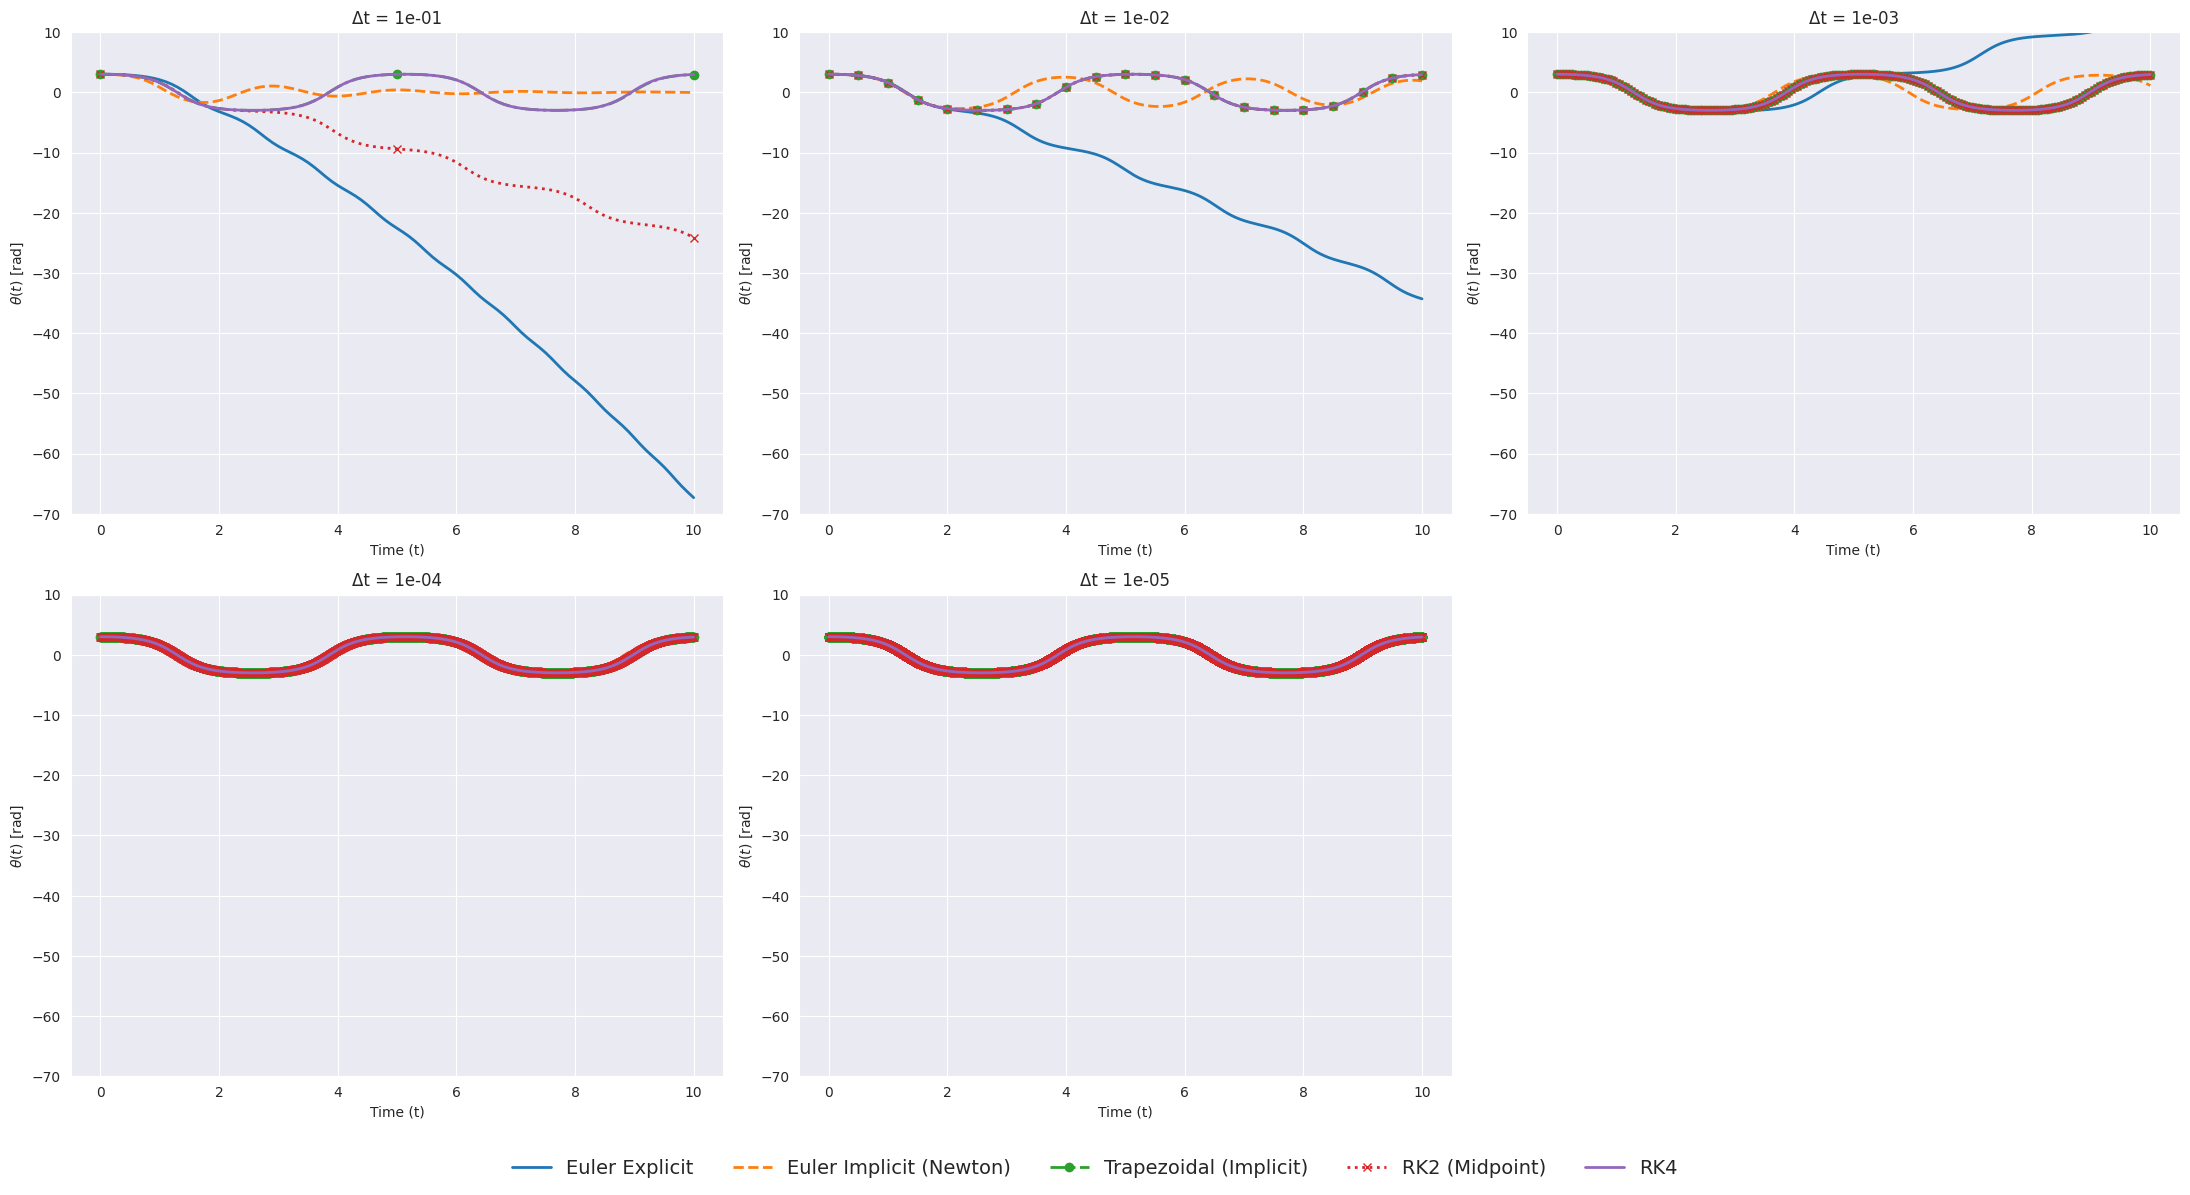

In [59]:
theta0 = 3.0
omega0 = 0.0
dt_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

methods = {
    'Euler Explicit': Pendulum.euler_explicit,
    'Euler Implicit (Newton)': Pendulum.euler_implicit_newton,
    'Trapezoidal (Implicit)': Pendulum.trapezoidal_newton,
    'RK2 (Midpoint)': Pendulum.rk2,
    'RK4': Pendulum.rk4
}

styles = {
    'Euler Explicit': {'color': 'tab:blue', 'linestyle': '-', 'linewidth': 2},
    'Euler Implicit (Newton)': {'color': 'tab:orange', 'linestyle': '--', 'linewidth': 2},
    'Trapezoidal (Implicit)': {'color': 'tab:green', 'linestyle': '-.', 'linewidth': 2, 'marker': 'o', 'markevery': 50},
    'RK2 (Midpoint)': {'color': 'tab:red', 'linestyle': ':', 'linewidth': 2, 'marker': 'x', 'markevery': 50},
    'RK4': {'color': 'tab:purple', 'linestyle': '-', 'linewidth': 2}
}

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

# Store line handles for global legend
handles = []
labels = []

for i, dt in enumerate(dt_values):
    pend = Pendulum(theta0, omega0, dt)
    ax = axes[i]

    for name, method_func in methods.items():
        t, theta, omega = method_func(pend)
        line, = ax.plot(t, theta, label=name, **styles[name])
        if i == 0:  # capture handles only once
            handles.append(line)
            labels.append(name)

    ax.set_title(f"Δt = {dt:.0e}")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel(r"$\theta(t)$ [rad]")
    ax.set_ylim(-70,10)
    ax.grid(True)

# Hide the extra (6th) subplot if unused
if len(dt_values) < len(axes):
    for j in range(len(dt_values), len(axes)):
        fig.delaxes(axes[j])

# Global legend at bottom center
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=14, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.show()


For $\Delta t =1 $ Newton Ralphson method wasnt able to converge.

### Stability, Accuracy and Phase shift

| **Method** | **Order of Accuracy** | **Stability** | **Phase Shift** |
|-------------|----------------------|----------------|------------------|
| **Euler Explicit** | 𝑂(Δt) | Conditionally stable | Large phase lead: because it overestimates the velocity, pushing the angle ahead in time |
| **Euler Implicit** | 𝑂(Δt) | Unconditionally stable | Large phase lag: the oscillation lags behind the true motion because the implicit formulation over-damps the system.|
| **Trapezoidal (Crank–Nicolson)** | 𝑂(Δt²) | Unconditionally stable | Small phase lag: minimal delay compared to implicit Euler. It provides nearly symmetric time stepping, so the oscillation’s phase remains close to exact |
| **RK2 (Midpoint)** | 𝑂(Δt²) | Conditionally stable | Slight phase lead: less than explicit Euler, but still advances slightly ahead of the true phase because it uses a midpoint estimate. |
| **RK4 (Classical)** | 𝑂(Δt⁴) | Conditionally stable | Minimal phase error: extremely small lead or lag, depending on $ \Delta t$.|


### **PROBLEM-2**

Write a code guaranteeing global 4th order accuracy to solve via shooting method :

$ y'' + 4y' + 3y = \sin(t^2)$

with the boundary conditions: $y(0) = 0, \quad y(1) = 1$

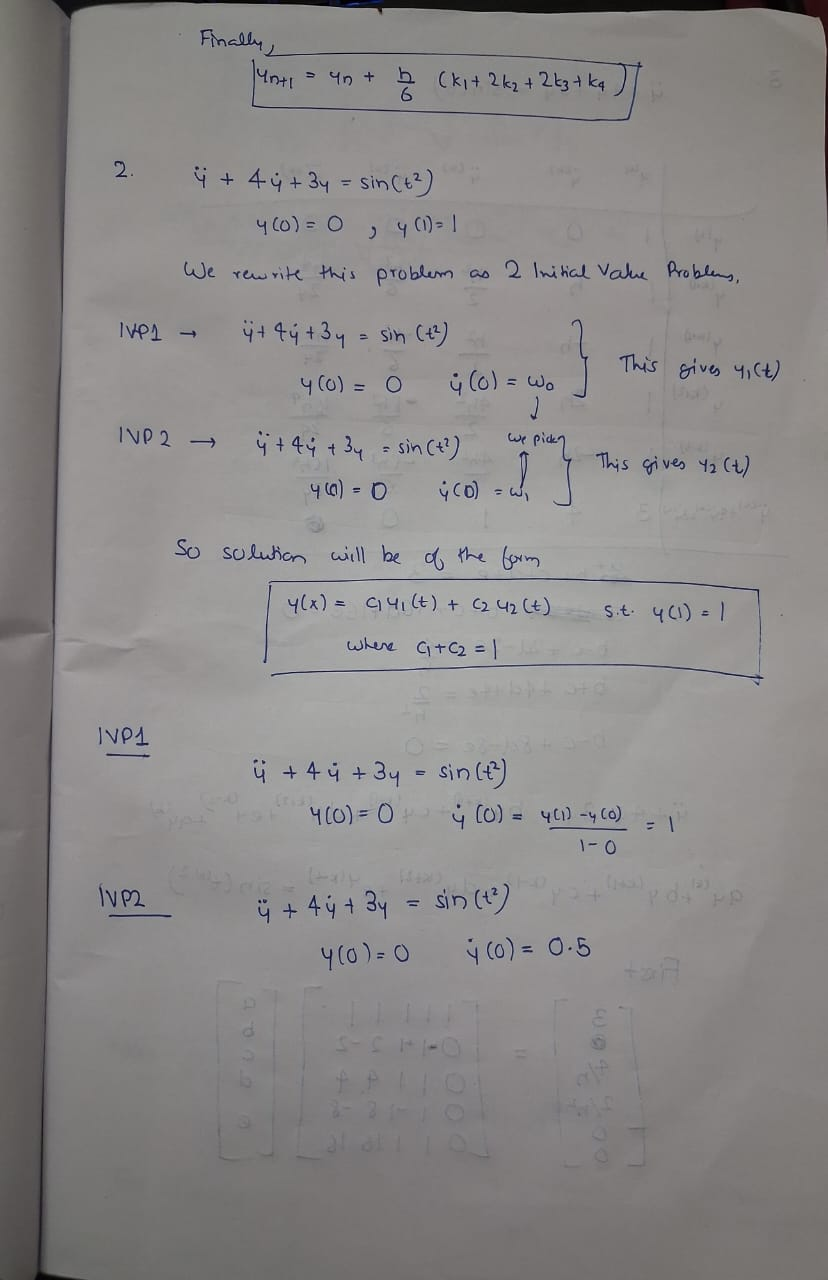

y1(1)=0.198477, y2(1)=0.516570
c1=-1.519780, c2=2.519780
y_comb(1)=1.000000


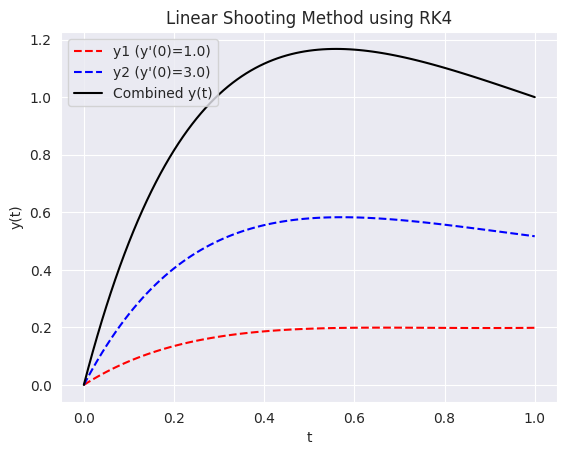

In [60]:
def f(t, Y):
    y, yp = Y
    return np.array([yp, np.sin(t**2) - 4*yp - 3*y])

# 4th-order Runge-Kutta step
def rk4_step(func, t, Y, h):
    k1 = func(t, Y)
    k2 = func(t + h/2, Y + h*k1/2)
    k3 = func(t + h/2, Y + h*k2/2)
    k4 = func(t + h, Y + h*k3)
    return Y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Solve IVP using RK4
def solve_ivp_rk4(y0, yp0, t0, t_end, h):
    n = int((t_end - t0)/h)
    t_vals = np.linspace(t0, t_end, n+1)
    Y = np.zeros((n+1, 2))
    Y[0] = [y0, yp0]
    for i in range(n):
        Y[i+1] = rk4_step(f, t_vals[i], Y[i], h)
    return t_vals, Y[:,0], Y[:,1]


h = 0.01
t0, t_end = 0, 1
t, y1, _ = solve_ivp_rk4(0, 1.0, t0, t_end, h)
_, y2, _ = solve_ivp_rk4(0, 3.0, t0, t_end, h)

# Combine linearly to satisfy y(1)=1
A = np.array([[y1[-1], y2[-1]],[1, 1]])
b = np.array([1, 1])
c1, c2 = np.linalg.solve(A, b)

# Combined solution
y_comb = c1*y1 + c2*y2

# Print coefficients and check
print(f"y1(1)={y1[-1]:.6f}, y2(1)={y2[-1]:.6f}")
print(f"c1={c1:.6f}, c2={c2:.6f}")
print(f"y_comb(1)={y_comb[-1]:.6f}")

# Plot
plt.plot(t, y1, 'r--', label='y1 (y\'(0)=1.0)')
plt.plot(t, y2, 'b--', label='y2 (y\'(0)=3.0)')
plt.plot(t, y_comb, 'k', label='Combined y(t)')
plt.legend()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Linear Shooting Method using RK4')
plt.grid(True)
plt.show()

### **PROBLEM-3**

For the above differential equation write a code guaranteeing global 4th order accuracy to solve via a direct method. Compare and comment

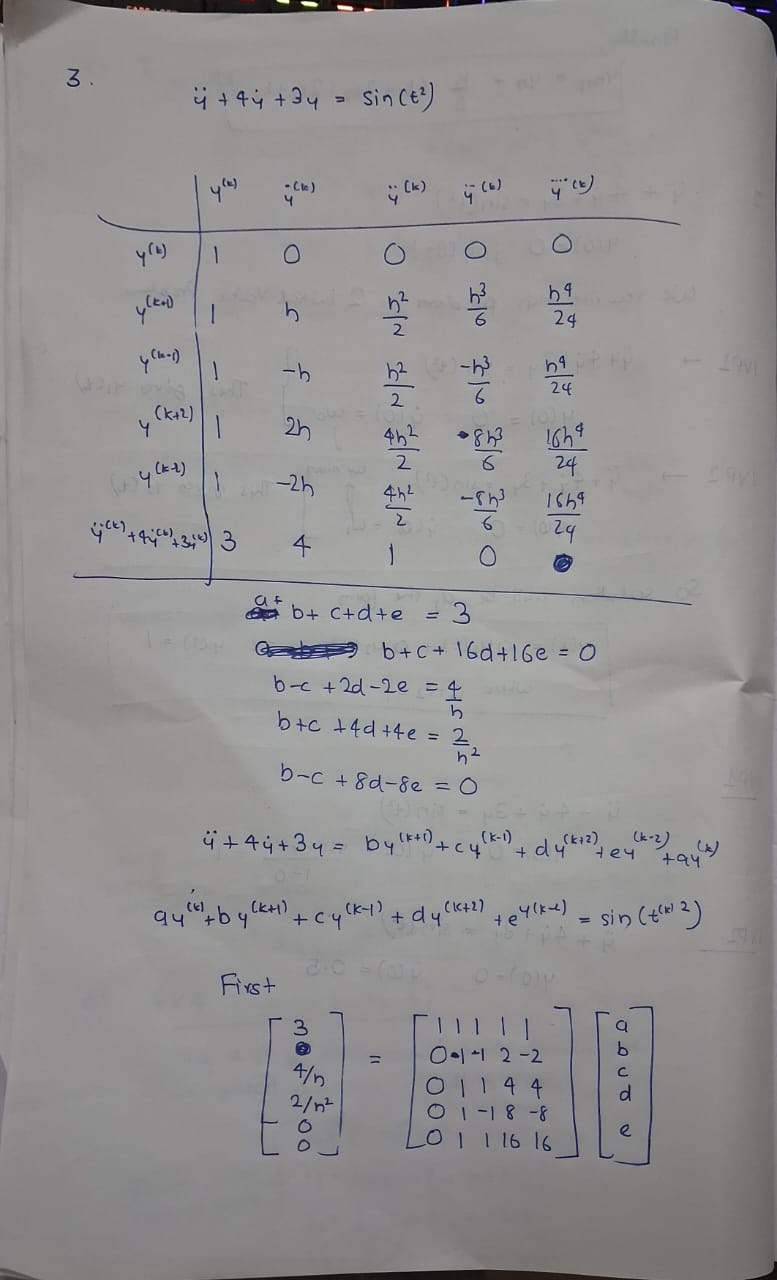

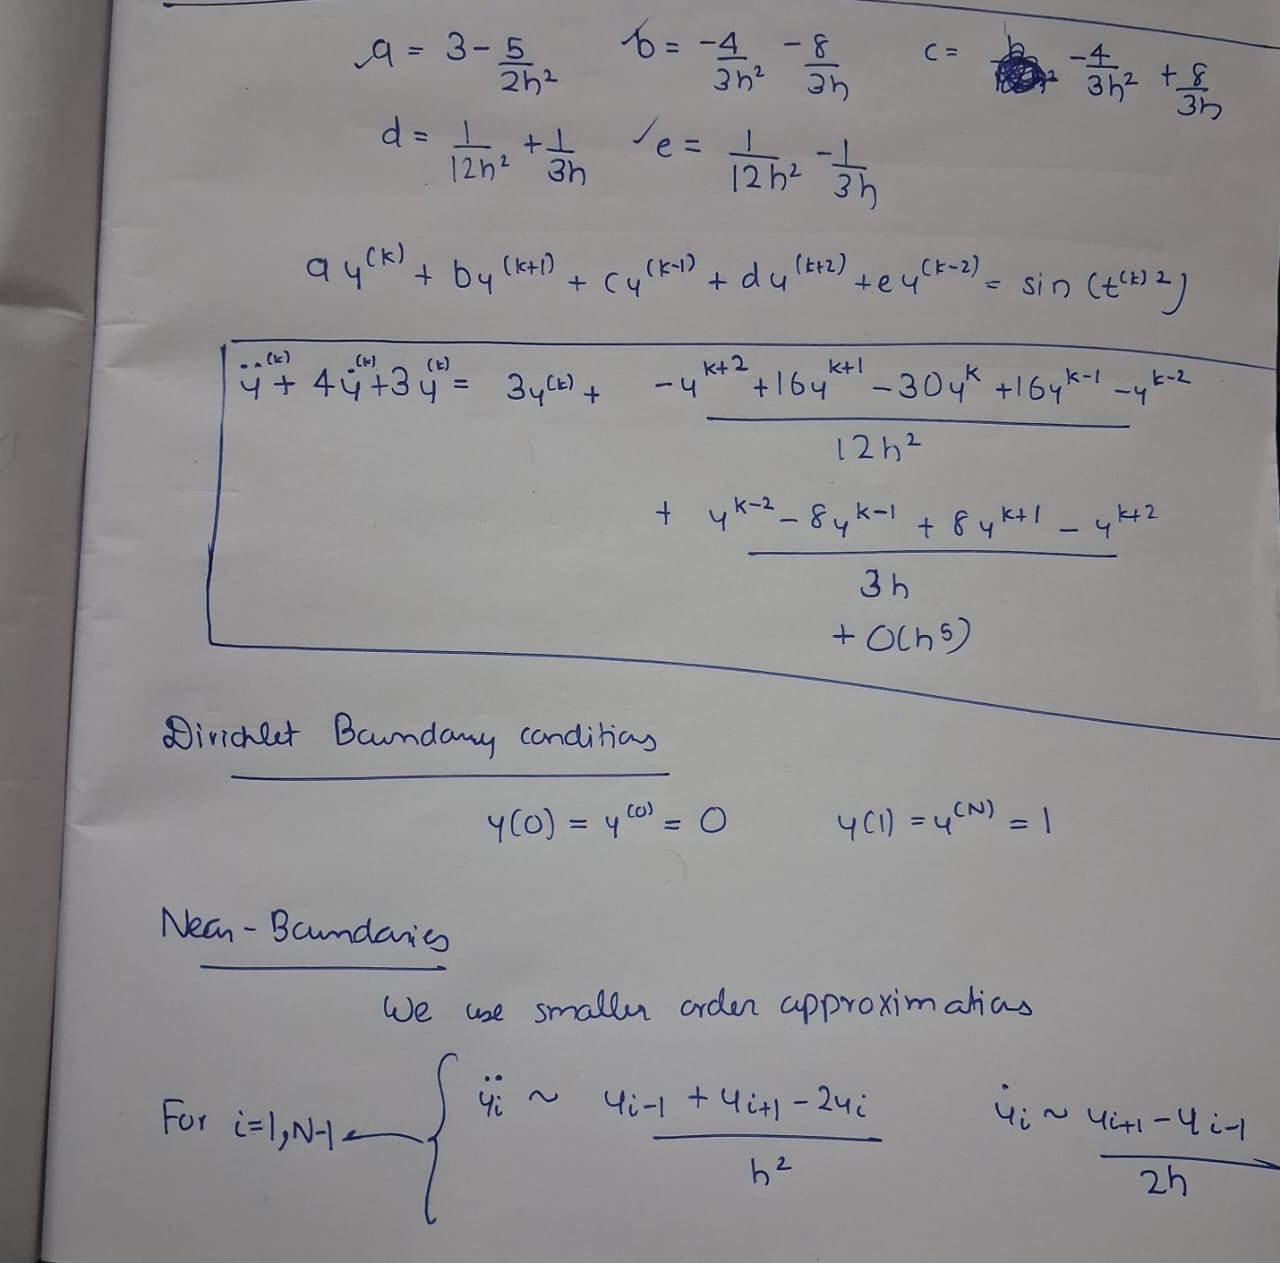

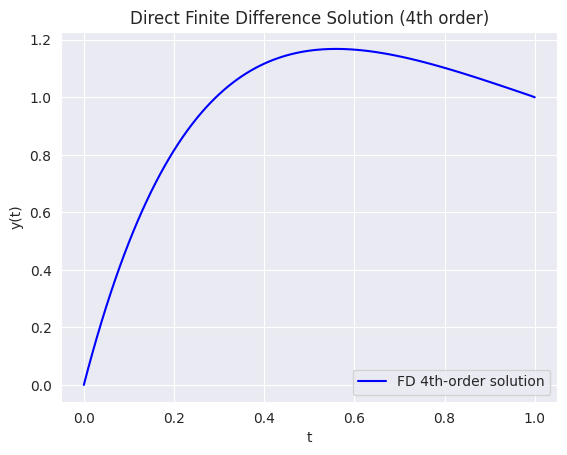

In [61]:
def solve_fd_4th_order(a=0, b=1, ya=0, yb=1, N=100):
    h = (b - a) / N
    t = np.linspace(a, b, N+1)

    A = np.zeros((N+1, N+1))
    F = np.zeros(N+1)

    # Interior points (4th-order scheme)
    for i in range(2, N-1):
        A[i, i-2] = (-1/(12*h**2) + 4/(12*h))
        A[i, i-1] = (16/(12*h**2) - 8*4/(12*h))
        A[i, i]   = (-30/(12*h**2) + 3)
        A[i, i+1] = (16/(12*h**2) + 8*4/(12*h))
        A[i, i+2] = (-1/(12*h**2) - 4/(12*h))
        F[i] = np.sin(t[i]**2)

    # Boundary conditions (Dirichlet)
    A[0, 0] = 1
    F[0] = ya
    A[-1, -1] = 1
    F[-1] = yb

    # One-sided lower-order approximations near boundaries (2nd order)
    i = 1
    A[i, i-1:i+2] = [1, -2, 1]
    A[i] /= h**2
    A[i, i-1] += -4/(2*h)
    A[i, i+1] += 4/(2*h)
    A[i, i] += 3
    F[i] = np.sin(t[i]**2)

    i = N-1
    A[i, i-1:i+2] = [1, -2, 1]
    A[i] /= h**2
    A[i, i-1] += 4/(2*h)
    A[i, i+1] += -4/(2*h)
    A[i, i] += 3
    F[i] = np.sin(t[i]**2)

    y = np.linalg.solve(A, F)
    return t, y

t, y = solve_fd_4th_order()

plt.plot(t, y, 'b-', label='FD 4th-order solution')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Direct Finite Difference Solution (4th order)')
plt.grid(True)
plt.legend()
plt.show()


#### **COMPARING SHOOTING METHOD WITH DIRECT METHOD OF ACCRUACY *O*($h^4$)**

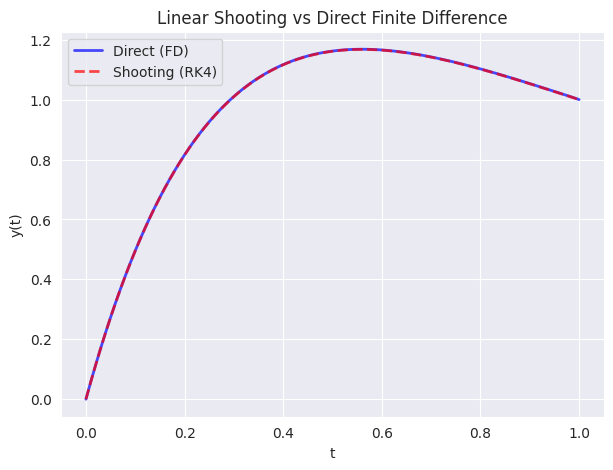

In [62]:
t, y = solve_fd_4th_order()

h = 0.01
t0, t_end = 0, 1
_, y1, _ = solve_ivp_rk4(0, 1.0, t0, t_end, h)
_, y2, _ = solve_ivp_rk4(0, 3.0, t0, t_end, h)

# Combine linearly to satisfy y(1)=1
A = np.array([[y1[-1], y2[-1]],[1, 1]])
b = np.array([1, 1])
c1, c2 = np.linalg.solve(A, b)

# Combined solution
y_comb = c1*y1 + c2*y2

plt.figure(figsize=(7,5))
plt.plot(t, y, 'b-', label='Direct (FD)', alpha=0.7, linewidth=2)
plt.plot(t, y_comb, 'r--', label='Shooting (RK4)', alpha=0.7, linewidth=2)
plt.legend()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Linear Shooting vs Direct Finite Difference')
plt.grid(True)
plt.show()


**OBSERVATIONS**

1. The numerical solutions obtained from the Direct Finite Difference method (4th-order accurate) and the Linear Shooting method (using 4th-order Runge–Kutta integration) are nearly indistinguishable on the plot, effectively tracing each other throughout the domain.

2. Both methods are globally 4th-order accurate, and hence the truncation errors are of the same order of magnitude.

3. The numerical stability of both schemes is well-maintained for the chosen step size $h=0.01$.